In [179]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import Lasso
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import datetime
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [151]:
car_dataset = pd.read_csv('/content/car details v4.csv')

In [152]:
car_dataset.head()

,Make,Model,Price,Year,Kilometer,Fuel_Type,Transmission,Location,Color,Owner,Seller_Type,Engine,Max_Power,Max_Torque,Drivetrain,Length,Width,Height,Seating_Capacity,Fuel_Tank_Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [153]:
car_dataset.isnull().sum()

,0
Make,0
Model,0
Price,0
Year,0
Kilometer,0
Fuel_Type,0
Transmission,0
Location,0
Color,0
Owner,0


In [154]:
car_dataset.shape

(2059, 20)

In [155]:
car_dataset['Engine'] = car_dataset['Engine'].astype(str).str.extract(r'(\d+\.?\d*)')[0]
car_dataset['Max_Power'] = car_dataset['Max_Power'].astype(str).str.extract(r'(\d+\.?\d*)')[0]
car_dataset['Max_Torque'] = car_dataset['Max_Torque'].astype(str).str.extract(r'(\d+\.?\d*)')[0]

car_dataset['Engine'] = pd.to_numeric(car_dataset['Engine'], errors='coerce')
car_dataset['Max_Power'] = pd.to_numeric(car_dataset['Max_Power'], errors='coerce')
car_dataset['Max_Torque'] = pd.to_numeric(car_dataset['Max_Torque'], errors='coerce')

In [156]:
num_cols = [
    'Engine', 'Max_Power', 'Max_Torque',
    'Length', 'Width', 'Height',
    'Seating_Capacity', 'Fuel_Tank_Capacity'
]

for col in num_cols:
    car_dataset[col] = car_dataset[col].fillna(car_dataset[col].median())

car_dataset['Drivetrain'] = car_dataset['Drivetrain'].fillna(car_dataset['Drivetrain'].mode()[0])

car_dataset.isnull().sum()

,0
Make,0
Model,0
Price,0
Year,0
Kilometer,0
Fuel_Type,0
Transmission,0
Location,0
Color,0
Owner,0


In [157]:
current_year = datetime.datetime.now().year
car_dataset['Car_Age'] = current_year - car_dataset['Year']

In [158]:
car_dataset.head()

,Make,Model,Price,Year,Kilometer,Fuel_Type,Transmission,Location,Color,Owner,Seller_Type,Engine,Max_Power,Max_Torque,Drivetrain,Length,Width,Height,Seating_Capacity,Fuel_Tank_Capacity,Car_Age
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198.0,87.0,109.0000,FWD,3990.0,1680.0,1505.0,5.0,35.0,9
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248.0,74.0,190.0000,FWD,3995.0,1695.0,1555.0,5.0,42.0,12
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197.0,79.0,112.7619,FWD,3585.0,1595.0,1550.0,5.0,35.0,15
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197.0,82.0,113.0000,FWD,3995.0,1745.0,1510.0,5.0,37.0,7
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393.0,148.0,343.0000,RWD,4735.0,1830.0,1795.0,7.0,55.0,8


In [159]:
car_dataset['Fuel_Type'].value_counts()

,count
Fuel_Type,
Diesel,1049
Petrol,942
CNG,50
Electric,7
LPG,5
Hybrid,3
CNG + CNG,1
Petrol + CNG,1
Petrol + LPG,1


In [160]:
car_dataset['Owner'].value_counts()

,count
Owner,
First,1619
Second,373
Third,42
UnRegistered Car,21
Fourth,3
4 or More,1


In [161]:
car_dataset['Fuel_Type'] = car_dataset['Fuel_Type'].replace({
    'CNG + CNG': 'CNG',
    'Petrol + CNG': 'Other',
    'Petrol + LPG': 'Other',
    'LPG': 'Other',
    'Hybrid': 'Other'
})

car_dataset['Owner'] = car_dataset['Owner'].replace({
    '4 or More': 'Third',
    'Fourth': 'Third'
})

In [162]:
car_dataset['Location'].value_counts()

,count
Location,
Mumbai,342
Delhi,307
Pune,144
Bangalore,132
Hyderabad,116
...,...
Valsad,1
Rohtak,1
Faizabad,1


In [163]:
top_locations = car_dataset['Location'].value_counts().nlargest(10).index
car_dataset['Location'] = car_dataset['Location'].apply(
    lambda x: x if x in top_locations else 'Other'
)

In [164]:
car_dataset['Location'].value_counts()

,count
Location,
Other,695
Mumbai,342
Delhi,307
Pune,144
Bangalore,132
Hyderabad,116
Lucknow,78
Ahmedabad,70
Chennai,63


In [165]:
car_dataset = car_dataset.drop(columns=['Color', 'Year'])

In [166]:
car_dataset.head()

,Make,Model,Price,Kilometer,Fuel_Type,Transmission,Location,Owner,Seller_Type,Engine,Max_Power,Max_Torque,Drivetrain,Length,Width,Height,Seating_Capacity,Fuel_Tank_Capacity,Car_Age
0,Honda,Amaze 1.2 VX i-VTEC,505000,87150,Petrol,Manual,Pune,First,Corporate,1198.0,87.0,109.0000,FWD,3990.0,1680.0,1505.0,5.0,35.0,9
1,Maruti Suzuki,Swift DZire VDI,450000,75000,Diesel,Manual,Other,Second,Individual,1248.0,74.0,190.0000,FWD,3995.0,1695.0,1555.0,5.0,42.0,12
2,Hyundai,i10 Magna 1.2 Kappa2,220000,67000,Petrol,Manual,Lucknow,First,Individual,1197.0,79.0,112.7619,FWD,3585.0,1595.0,1550.0,5.0,35.0,15
3,Toyota,Glanza G,799000,37500,Petrol,Manual,Other,First,Individual,1197.0,82.0,113.0000,FWD,3995.0,1745.0,1510.0,5.0,37.0,7
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,69000,Diesel,Manual,Mumbai,First,Individual,2393.0,148.0,343.0000,RWD,4735.0,1830.0,1795.0,7.0,55.0,8


In [170]:
X = car_dataset.drop(columns=['Price', 'Make', 'Model'])
Y = np.log(car_dataset['Price'])

In [171]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,Kilometer,Engine,Max_Power,Max_Torque,Length,Width,Height,Seating_Capacity,Fuel_Tank_Capacity,Car_Age,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Other,Fuel_Type_Petrol,Transmission_Manual,Location_Bangalore,Location_Chennai,Location_Delhi,Location_Hyderabad,Location_Kanpur,Location_Kolkata,Location_Lucknow,Location_Mumbai,Location_Other,Location_Pune,Owner_Second,Owner_Third,Owner_UnRegistered Car,Seller_Type_Corporate,Seller_Type_Individual,Drivetrain_FWD,Drivetrain_RWD
0,87150,1198.0,87.0,109.0000,3990.0,1680.0,1505.0,5.0,35.0,9,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False
1,75000,1248.0,74.0,190.0000,3995.0,1695.0,1555.0,5.0,42.0,12,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,True,False
2,67000,1197.0,79.0,112.7619,3585.0,1595.0,1550.0,5.0,35.0,15,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False
3,37500,1197.0,82.0,113.0000,3995.0,1745.0,1510.0,5.0,37.0,7,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True,False
4,69000,2393.0,148.0,343.0000,4735.0,1830.0,1795.0,7.0,55.0,8,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True


In [172]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [181]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [188]:
linr_reg_model = LinearRegression()
linr_reg_model.fit(X_train, Y_train)

training_reg_prediction = linr_reg_model.predict(X_train)

In [194]:
lr_r2 = metrics.r2_score(Y_train, training_reg_prediction)
lr_mae = mean_absolute_error(Y_train, training_reg_prediction)
lr_mse = mean_squared_error(Y_train, training_reg_prediction)
lr_rmse = np.sqrt(mean_squared_error(Y_train, training_reg_prediction))

print("Linear Regression Results on Training Data")
print("Training R2 Score :", lr_r2)
print("Training MAE      :", lr_mae)
print("Training RMSE     :", lr_rmse)
print("Training MSE       :", lr_mse)

Linear Regression Results on Training Data
Training R2 Score : 0.9086944808697266
Training MAE      : 0.21021064887310617
Training RMSE     : 0.2970618248147858
Training MSE       : 0.08824572776229052


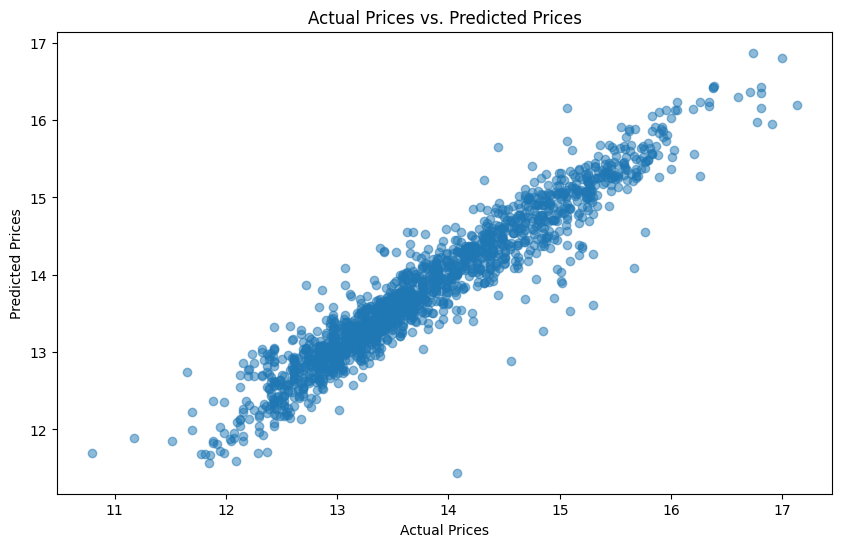

In [195]:
# Visualize the actual prices and predicted prices

plt.figure(figsize=(10, 6))
plt.scatter(Y_train, training_reg_prediction, alpha=0.5)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual Prices vs. Predicted Prices')
plt.show()

In [196]:
test_reg_prediction = linr_reg_model.predict(X_test)

In [197]:
lr_r2 = metrics.r2_score(Y_test, test_reg_prediction)
lr_mae = mean_absolute_error(Y_test, test_reg_prediction)
lr_mse = mean_squared_error(Y_test, test_reg_prediction)
lr_rmse = np.sqrt(mean_squared_error(Y_test, test_reg_prediction))

print("Linear Regression Results on Test data")
print("Test R2 Score :", lr_r2)
print("Test MAE      :", lr_mae)
print("Test RMSE     :", lr_rmse)
print("Test MSE       :", lr_mse)

Linear Regression Results on Test data
Test R2 Score : 0.9099175354942546
Test MAE      : 0.20813431368684798
Test RMSE     : 0.2913772826417529
Test MSE       : 0.08490072083969194


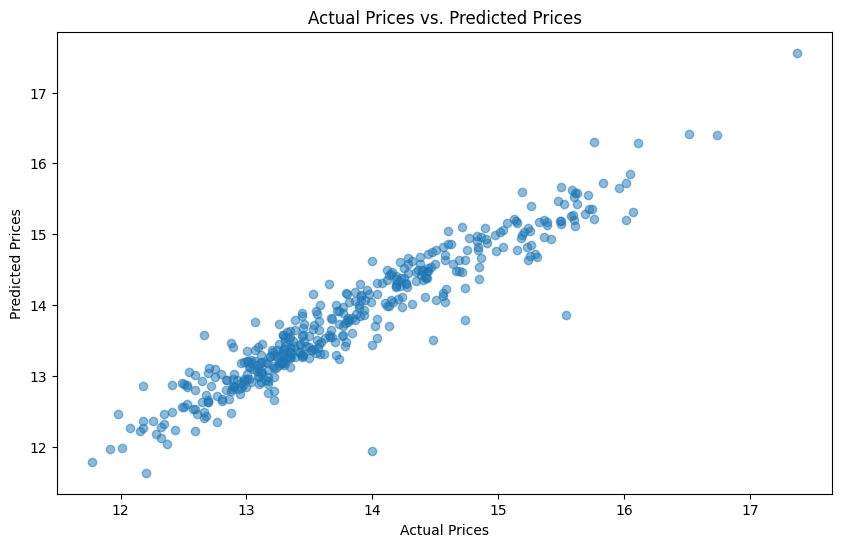

In [199]:
# Visualize the actual prices and predicted prices

plt.figure(figsize=(10, 6))
plt.scatter(Y_test, test_reg_prediction, alpha=0.5)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual Prices vs. Predicted Prices')
plt.show()

Lasso Regression

In [219]:
lasso_reg_model = Lasso(alpha=0.01)
lasso_reg_model.fit(X_train, Y_train)

training_reg_prediction = lasso_reg_model.predict(X_train)

In [220]:
lr_r2 = metrics.r2_score(Y_train, training_reg_prediction)
lr_mae = mean_absolute_error(Y_train, training_reg_prediction)
lr_mse = mean_squared_error(Y_train, training_reg_prediction)
lr_rmse = np.sqrt(mean_squared_error(Y_train, training_reg_prediction))

print("Lasso Regression Results on Training Data")
print("Training R2 Score :", lr_r2)
print("Training MAE      :", lr_mae)
print("Training RMSE     :", lr_rmse)
print("Training MSE       :", lr_mse)

Lasso Regression Results on Training Data
Training R2 Score : 0.9062837217081721
Training MAE      : 0.21152816121589274
Training RMSE     : 0.3009579681575843
Training MSE       : 0.09057569859754153


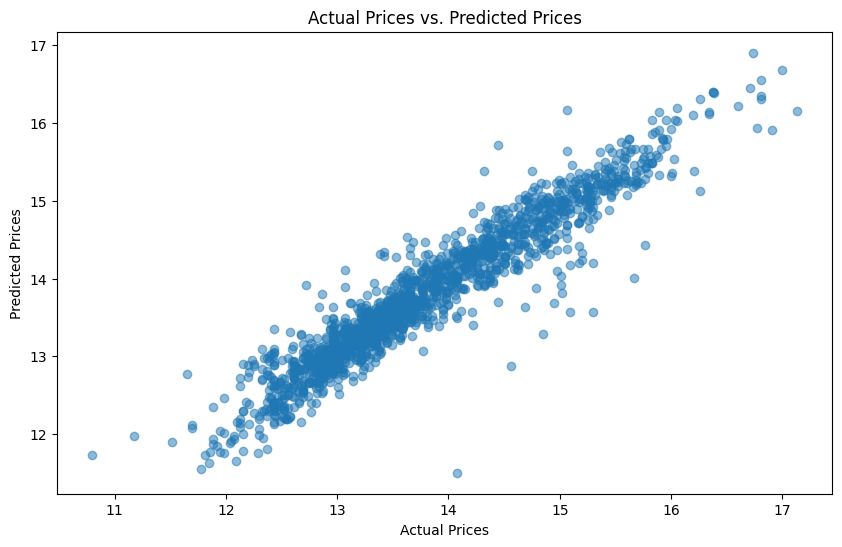

In [221]:
# Visualize the actual prices and predicted prices

plt.figure(figsize=(10, 6))
plt.scatter(Y_train, training_reg_prediction, alpha=0.5)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual Prices vs. Predicted Prices')
plt.show()

In [222]:
test_reg_prediction = lasso_reg_model.predict(X_test)

In [223]:
lr_r2 = metrics.r2_score(Y_test, test_reg_prediction)
lr_mae = mean_absolute_error(Y_test, test_reg_prediction)
lr_mse = mean_squared_error(Y_test, test_reg_prediction)
lr_rmse = np.sqrt(mean_squared_error(Y_test, test_reg_prediction))

print("Lasso Regression Results on Test data")
print("Test R2 Score :", lr_r2)
print("Test MAE      :", lr_mae)
print("Test RMSE     :", lr_rmse)
print("Test MSE       :", lr_mse)

Lasso Regression Results on Test data
Test R2 Score : 0.9088488667657079
Test MAE      : 0.21000757128319064
Test RMSE     : 0.29310052433708994
Test MSE       : 0.08590791736667706
